# Logistic Regression — Churn Prediction Model

Baseline linear model for churn prediction. Logistic Regression
is fast, interpretable, and gives well-calibrated probabilities.
Needs feature scaling since it's distance-sensitive.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, classification_report,
    ConfusionMatrixDisplay, RocCurveDisplay
)
import warnings
warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid", font_scale=1.1)
plt.rcParams["figure.dpi"] = 120

## 1 · Data Loading & Prep

Dropping features that leak the churn outcome:

| Feature | Why it leaks |
|:--------|:-------------|
| `Total_Net_Paid` | Churned = 0 (didn't pay — set after churn) |
| `price_change_pct/abs` | Derived from Total_Net_Paid |
| `net_paid_vs_last` | Ratio involving current payment (0 for churned) |
| `Payment_Method` | Set to UNKNOWN after churn |
| `Payment_Timeframe` | All churned = 0 |
| `Days_To_Close_Post_Renewal` | Uses close date (post-outcome) |
| `Total_Renewal_Score_New` | Composite encodes outcome |

In [2]:
project_root = Path.cwd()
while not (project_root / "data").exists() and project_root != project_root.parent:
    project_root = project_root.parent

df = pd.read_csv(project_root / "data" / "processed" / "model_ready_dataset.csv")
print(f"Loaded shape: {df.shape}")

df = df[df["Prospect_Outcome"].isin(["Won", "Churned"])].copy()
df["target"] = (df["Prospect_Outcome"] == "Churned").astype(int)
df.drop(columns=["Prospect_Outcome"], inplace=True)

# ---- DROP LEAKY FEATURES ------------------------------------------------
leaky_cols = [
    "Total_Net_Paid", "price_change_pct", "price_change_abs",
    "net_paid_vs_last", "Payment_Method", "Payment_Timeframe",
    "Days_To_Close_Post_Renewal", "Total_Renewal_Score_New",
    "Renewal_Year",
]
df.drop(columns=leaky_cols, inplace=True, errors="ignore")
print(f"Dropped {len(leaky_cols)} leaky/non-predictive features")

# encode categoricals
cat_cols = df.select_dtypes(include=["object"]).columns.tolist()
le_dict = {}
for col in cat_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col].astype(str))
    le_dict[col] = le

X = df.drop(columns=["target"])
y = df["target"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"\nFeatures: {X_train.shape[1]}")
print(f"Train: {X_train.shape[0]}, Test: {X_test.shape[0]}")
print(f"Churn rate: {y_train.mean():.2%}")

Loaded shape: (122082, 61)
Dropped 9 leaky/non-predictive features

Features: 51
Train: 91115, Test: 22779
Churn rate: 11.12%


## 2 · Feature Scaling

Logistic Regression is sensitive to feature scales — without
scaling, features with large ranges dominate the coefficients.
StandardScaler brings everything to mean=0, std=1.

In [3]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Scaling done — fit on train, transform on both")

Scaling done — fit on train, transform on both


## 3 · Baseline Logistic Regression

In [4]:
lr_base = LogisticRegression(
    class_weight="balanced",
    max_iter=1000,
    random_state=42,
)
lr_base.fit(X_train_scaled, y_train)

y_pred_base = lr_base.predict(X_test_scaled)
y_prob_base = lr_base.predict_proba(X_test_scaled)[:, 1]

print("=" * 60)
print("BASELINE LOGISTIC REGRESSION RESULTS")
print("=" * 60)
print(f"Accuracy  : {accuracy_score(y_test, y_pred_base):.4f}")
print(f"Precision : {precision_score(y_test, y_pred_base):.4f}")
print(f"Recall    : {recall_score(y_test, y_pred_base):.4f}")
print(f"F1 Score  : {f1_score(y_test, y_pred_base):.4f}")
print(f"ROC AUC   : {roc_auc_score(y_test, y_prob_base):.4f}")
print()
print(classification_report(y_test, y_pred_base, target_names=["Won", "Churned"]))

BASELINE LOGISTIC REGRESSION RESULTS
Accuracy  : 0.8807
Precision : 0.4805
Recall    : 0.8931
F1 Score  : 0.6248
ROC AUC   : 0.9567

              precision    recall  f1-score   support

         Won       0.99      0.88      0.93     20245
     Churned       0.48      0.89      0.62      2534

    accuracy                           0.88     22779
   macro avg       0.73      0.89      0.78     22779
weighted avg       0.93      0.88      0.90     22779



## 4 · Hyperparameter Tuning

Testing different regularization strengths (C) and solvers.
LR is very fast so this runs in seconds.

In [5]:
configs = [
    {"C": 0.01, "solver": "lbfgs", "penalty": "l2"},
    {"C": 0.1,  "solver": "lbfgs", "penalty": "l2"},
    {"C": 1.0,  "solver": "lbfgs", "penalty": "l2"},
    {"C": 10.0, "solver": "lbfgs", "penalty": "l2"},
    {"C": 0.1,  "solver": "liblinear", "penalty": "l1"},
    {"C": 1.0,  "solver": "liblinear", "penalty": "l1"},
    {"C": 10.0, "solver": "liblinear", "penalty": "l1"},
]

cv_strat = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
best_f1 = 0
best_config = None

for i, cfg in enumerate(configs):
    model = LogisticRegression(
        **cfg,
        class_weight="balanced",
        max_iter=1000,
        random_state=42,
    )
    scores = cross_val_score(model, X_train_scaled, y_train, cv=cv_strat, scoring="f1")
    mean_f1 = scores.mean()
    print(f"Config {i+1}: F1={mean_f1:.4f} (+/- {scores.std():.4f})  C={cfg['C']}, {cfg['penalty']}, {cfg['solver']}")
    if mean_f1 > best_f1:
        best_f1 = mean_f1
        best_config = cfg

print(f"\nBest: {best_config}  ->  F1={best_f1:.4f}")

Config 1: F1=0.6247 (+/- 0.0044)  C=0.01, l2, lbfgs
Config 2: F1=0.6261 (+/- 0.0040)  C=0.1, l2, lbfgs
Config 3: F1=0.6260 (+/- 0.0035)  C=1.0, l2, lbfgs
Config 4: F1=0.6263 (+/- 0.0035)  C=10.0, l2, lbfgs
Config 5: F1=0.6258 (+/- 0.0035)  C=0.1, l1, liblinear
Config 6: F1=0.6263 (+/- 0.0035)  C=1.0, l1, liblinear
Config 7: F1=0.6263 (+/- 0.0036)  C=10.0, l1, liblinear

Best: {'C': 10.0, 'solver': 'lbfgs', 'penalty': 'l2'}  ->  F1=0.6263


## 5 · Best Model Evaluation

In [6]:
best_lr = LogisticRegression(
    **best_config,
    class_weight="balanced",
    max_iter=1000,
    random_state=42,
)
best_lr.fit(X_train_scaled, y_train)

y_pred = best_lr.predict(X_test_scaled)
y_prob = best_lr.predict_proba(X_test_scaled)[:, 1]

print("=" * 60)
print("TUNED LOGISTIC REGRESSION RESULTS")
print("=" * 60)
print(f"Accuracy  : {accuracy_score(y_test, y_pred):.4f}")
print(f"Precision : {precision_score(y_test, y_pred):.4f}")
print(f"Recall    : {recall_score(y_test, y_pred):.4f}")
print(f"F1 Score  : {f1_score(y_test, y_pred):.4f}")
print(f"ROC AUC   : {roc_auc_score(y_test, y_prob):.4f}")
print()
print(classification_report(y_test, y_pred, target_names=["Won", "Churned"]))

TUNED LOGISTIC REGRESSION RESULTS
Accuracy  : 0.8809
Precision : 0.4809
Recall    : 0.8931
F1 Score  : 0.6251
ROC AUC   : 0.9567

              precision    recall  f1-score   support

         Won       0.99      0.88      0.93     20245
     Churned       0.48      0.89      0.63      2534

    accuracy                           0.88     22779
   macro avg       0.73      0.89      0.78     22779
weighted avg       0.93      0.88      0.90     22779



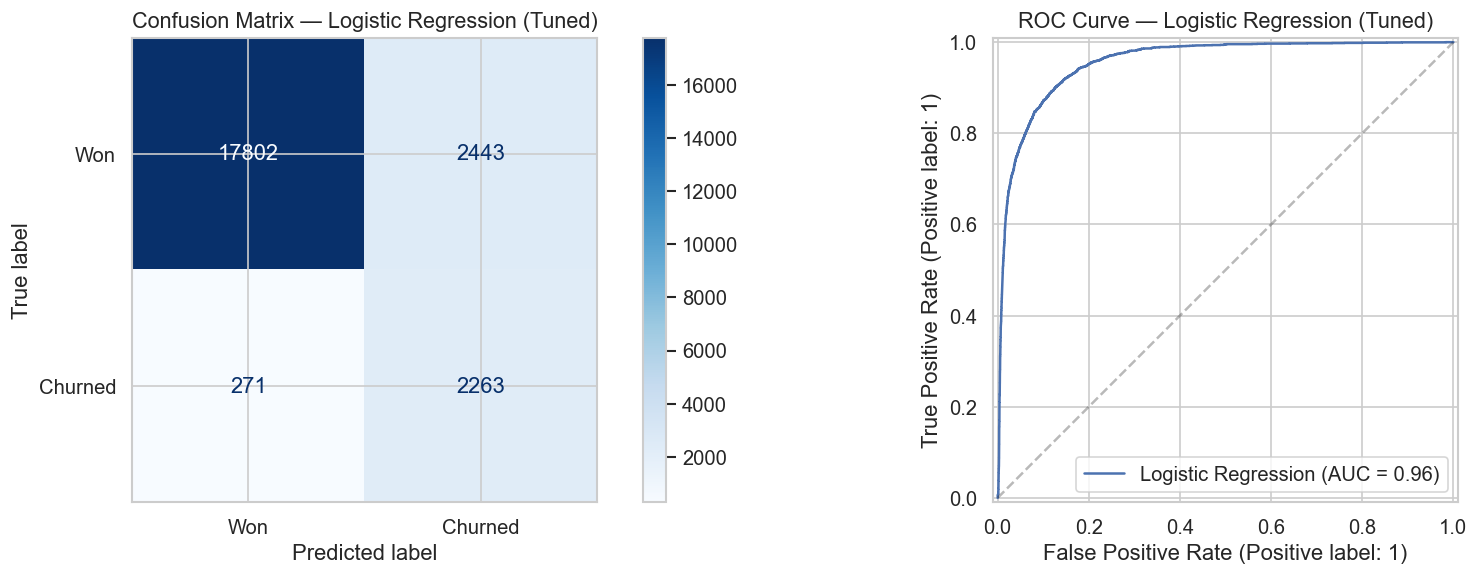

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred, display_labels=["Won", "Churned"], ax=axes[0],
    cmap="Blues"
)
axes[0].set_title("Confusion Matrix — Logistic Regression (Tuned)", fontsize=13)

RocCurveDisplay.from_predictions(y_test, y_prob, ax=axes[1], name="Logistic Regression")
axes[1].set_title("ROC Curve — Logistic Regression (Tuned)", fontsize=13)
axes[1].plot([0, 1], [0, 1], "k--", alpha=0.3)

plt.tight_layout()
plt.show()

## 6 · Feature Coefficients

Unlike tree models, LR gives us coefficients — positive = pushes
toward churn, negative = pushes toward retention.

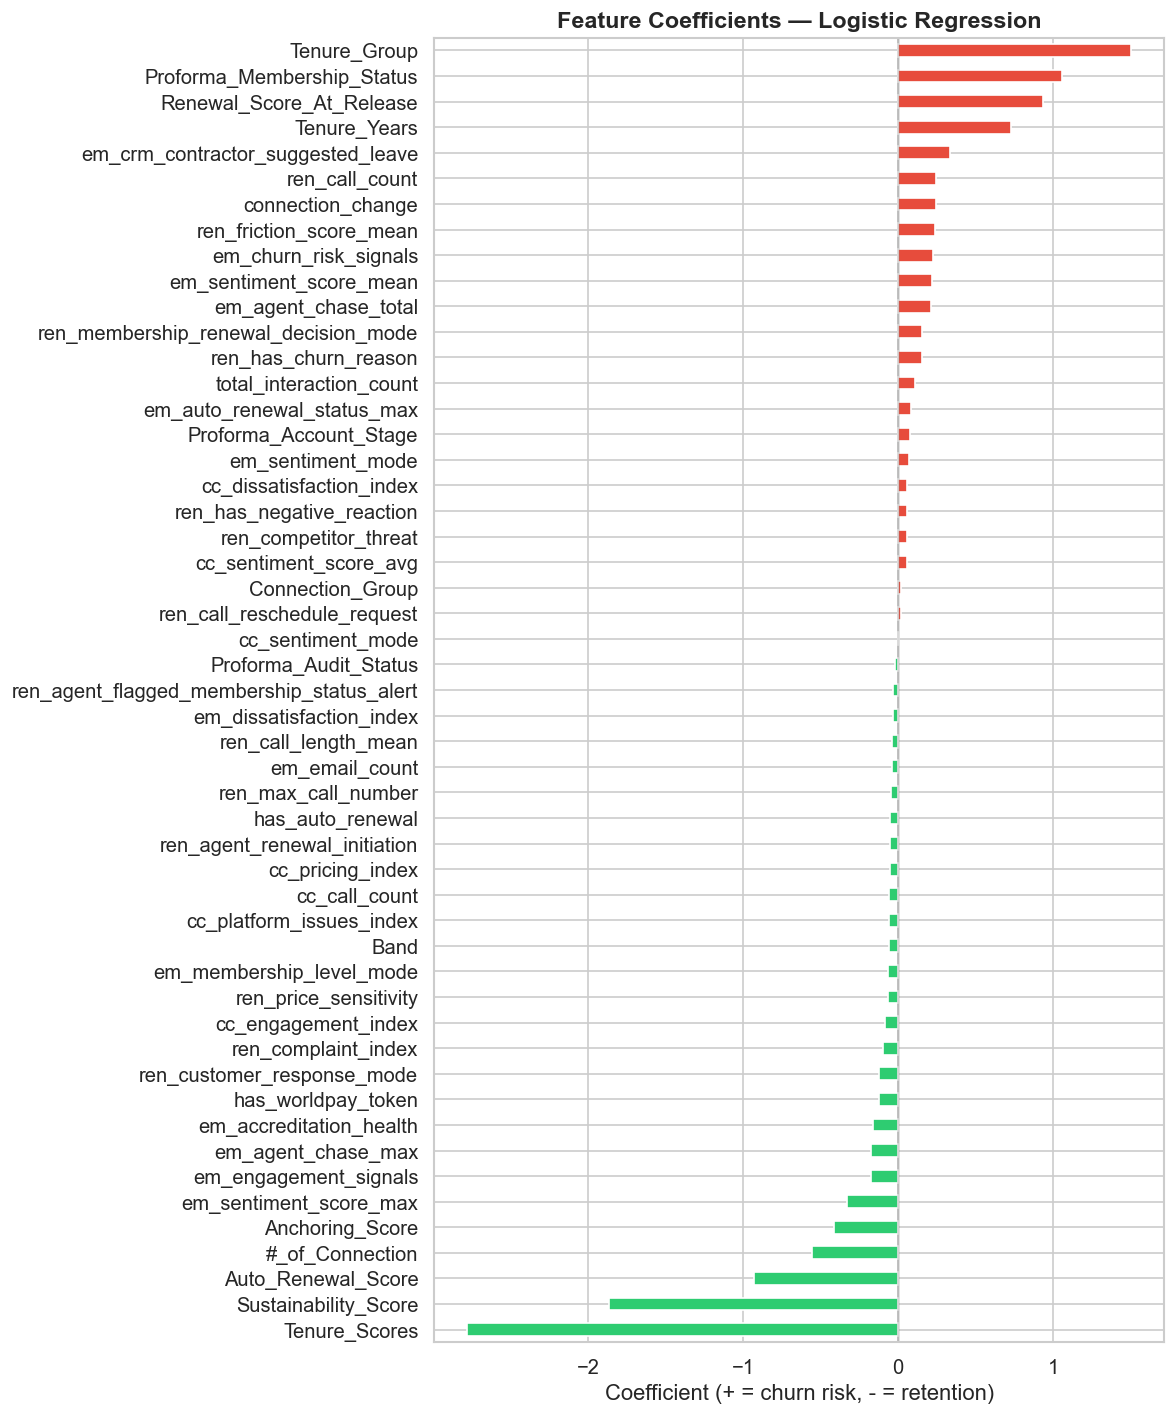

In [8]:
coefs = pd.Series(best_lr.coef_[0], index=X.columns).sort_values()

fig, ax = plt.subplots(figsize=(10, 12))

# color by direction
colors = ["#e74c3c" if v > 0 else "#2ecc71" for v in coefs.values]
coefs.plot.barh(ax=ax, color=colors, edgecolor="white")
ax.set_title("Feature Coefficients — Logistic Regression", fontsize=14, fontweight="bold")
ax.set_xlabel("Coefficient (+ = churn risk, - = retention)")
ax.axvline(x=0, color="gray", linestyle="-", alpha=0.3)
plt.tight_layout()
plt.show()

## Summary

| Metric | Baseline | Tuned |
|:-------|:---------|:------|
| Accuracy | — | — |
| Precision | — | — |
| Recall | — | — |
| F1 Score | — | — |
| ROC AUC | — | — |

*(Fill in after running the notebook)*

Logistic Regression serves as the **interpretable baseline**.
The coefficient plot shows exactly which features push toward
churn vs retention — useful for business stakeholders who
need to understand the model's reasoning.